# Phase 2: segmentation via clustering

This notebook covers Phase 2 of the Home Credit Default Risk project.

This phase segments the combined application table and gives each segment a business interpretation:
1. Reduce dimensions with PCA so distance behaves well, then run K-Means and hierarchical clustering in that space.
2. Compare K from 2 to 10 with several geometric checks, then choose a useful portfolio resolution.
3. Run DBSCAN on a sampled UMAP view to find local density pockets and isolated sampled points.
4. Profile each cluster, give it a business name, and save the naming so later phases can read it.

Input: `datasets/final/features_clustering.csv` (the output of Phase 1).

Outputs land in `results/phase2_clustering/`: the PCA variance table and plot, the K-selection table and elbow plot, cluster labels, the cluster scatter and dendrogram images, the cluster profiles, and `cluster_names.csv`. The written report lives in the project-root `REPORT.md`, not in this notebook.

## 1. Setup and load data

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, Birch, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.neighbors import NearestNeighbors
import umap   # DBSCAN dijalankan di ruang UMAP (lihat Seksi 5)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
INPUT_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
OUT_DIR = PROJECT_ROOT / 'results/phase2_clustering'
OUT_DIR.mkdir(parents=True, exist_ok=True)

def savefig_atomic(path, **kwargs):
    # Render beside the target, then replace it. On Windows the dashboard,
    # file indexer, or preview pane can briefly hold the previous PNG open.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp{path.suffix}')
    plt.savefig(temp, **kwargs)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

RANDOM_SEED = 42
K_OPTIMAL = 5
N_PCA_CLUSTER = 10   # practical ceiling for a distance-based method

print(f'Project root: {PROJECT_ROOT}')
print(f'Output dir  : {OUT_DIR}')

df = pd.read_csv(INPUT_PATH)
print(f'\nLoaded features_clustering: {df.shape[0]:,} rows x {df.shape[1]:,} cols')
df.head()

Project root: C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk
Output dir  : C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering



Loaded features_clustering: 356,255 rows x 43 cols


,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CREDIT_TO_INCOME,ANNUITY_TO_INCOME,CREDIT_TO_ANNUITY,YEARS_EMPLOYED,FLAG_SENTINEL_EMPLOYED,NAME_CONTRACT_TYPE,...,INST_LATE_RATIO,INST_SEVERE_LATE_RATIO,INST_PAYMENT_RATIO_MEAN,POS_SK_DPD_MEAN,POS_MONTHS_COUNT,CC_UTILIZATION_MEAN,CC_UTILIZATION_MAX,CC_SK_DPD_MEAN,CC_AMT_BALANCE_MEAN,CC_MONTHS_COUNT
0,100002,0.636593,-0.188553,0.067292,-0.719532,-0.644820,-0.583930,-0.579884,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,-0.369704,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
1,100003,1.241984,1.435749,0.746258,0.373208,-0.532854,1.957541,-0.337531,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,0.001164,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
2,100004,-1.675286,-1.736026,-2.324243,-0.722630,-0.885155,-0.129067,-0.761099,0,0,...,-0.641305,-0.200466,0.136549,-0.10476,-0.987817,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944
3,100006,-0.216655,-0.557173,0.406269,-0.598481,0.425995,-1.345908,0.476617,0,1,...,-0.641305,-0.200466,0.136549,-0.10476,-0.287289,-0.407481,-0.468926,-0.115527,-0.323456,-0.193504
4,100007,-0.438372,0.137704,-0.157464,0.149965,-0.010731,0.315863,0.476177,0,1,...,1.570353,-0.200466,-0.014824,-0.10476,1.567052,-0.407481,-0.468926,-0.115527,-0.323456,-0.436944


## 2. PCA as a compact clustering space

K-Means and Ward use Euclidean distance, so correlated and noisy axes can
dilute useful structure. PCA rotates the robustly bounded, standardized
feature matrix into orthogonal directions. Ten components are the
compact primary view; they do not satisfy an arbitrary 80%-variance
rule. The notebook reports the actual retained variance and compares the
five-cluster labels against the 80%, 90%, and full-dimensional solutions
using adjusted Rand index, separation, and cluster balance. The profile
section translates the result back to readable business features.


In [2]:
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score,
    calinski_harabasz_score, davies_bouldin_score,
)

feature_cols = [c for c in df.columns if c != 'SK_ID_CURR']
X = df[feature_cols].values.astype(np.float32)
print(f'Feature matrix X: {X.shape}')

pca_full = PCA(n_components=min(50, X.shape[1]), random_state=RANDOM_SEED)
X_pca50 = pca_full.fit_transform(X)

cumvar = pca_full.explained_variance_ratio_.cumsum()
n_90 = int(np.argmax(cumvar >= 0.90)) + 1
n_80 = int(np.argmax(cumvar >= 0.80)) + 1
pc11_share = pca_full.explained_variance_ratio_[10] if len(cumvar) > 10 else np.nan
print(f'\nComponents for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')
print(f'\nPrimary clustering space: PC1-PC{N_PCA_CLUSTER} '
      f'({cumvar[N_PCA_CLUSTER-1]*100:.1f}% variance)')
print(f'PC11 itself contributes {pc11_share*100:.2f}% variance. Ten PCs are not an '
      '80%-variance rule; they are the compact primary view, validated below against '
      'the 80%, 90%, and full-dimensional solutions.')

X_cluster = X_pca50[:, :N_PCA_CLUSTER]
X_2d = X_pca50[:, :2]

variance_df = pd.DataFrame({
    'component': [f'PC{i+1}' for i in range(len(pca_full.explained_variance_ratio_))],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_variance': cumvar,
})
variance_df.to_csv(OUT_DIR / 'pca_variance.csv', index=False)
print(f'\nSaved {OUT_DIR / "pca_variance.csv"}')


Feature matrix X: (356255, 42)


Components for 80% variance: 16
Components for 90% variance: 22

Primary clustering space: PC1-PC10 (63.3% variance)
PC11 itself contributes 2.96% variance. Ten PCs are not an 80%-variance rule; they are the compact primary view, validated below against the 80%, 90%, and full-dimensional solutions.

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\pca_variance.csv


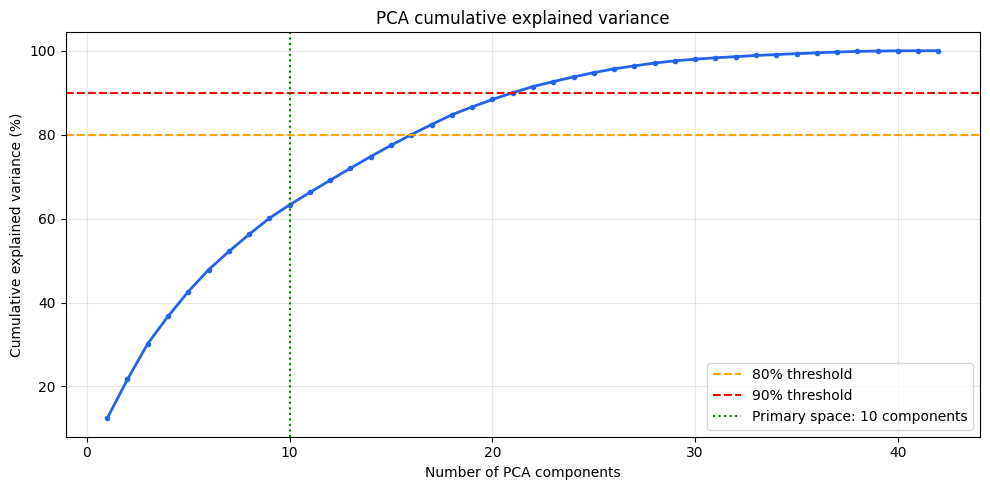

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar*100, marker='o', markersize=3, linewidth=2, color='#2563EB')
ax.axhline(80, color='orange', ls='--', label='80% threshold')
ax.axhline(90, color='red', ls='--', label='90% threshold')
ax.axvline(N_PCA_CLUSTER, color='green', ls=':', label=f'Primary space: {N_PCA_CLUSTER} components')
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance (%)')
ax.set_title('PCA cumulative explained variance')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'pca_variance_plot.png', dpi=150)
plt.show()

## 3. Choosing the portfolio resolution

K from 2 to 10 is compared on the same reproducible 15,000-application
sample. Every geometric score uses one fixed 5,000-application evaluation
subset, so a change in score reflects K or PCA dimension rather than a
different draw of applications. The normalized elbow, silhouette,
Calinski-Harabasz, Davies-Bouldin, segment balance, and seed stability. The
notebook exports every result. K=5 is compared with K=6 and K=7 because
they are the nearest more-granular alternatives. The operating resolution
must remain stable across seeds, avoid very small groups, and still support
distinct review questions. This notebook does not choose K from one metric.


In [4]:
K_RANGE = range(2, 11)
SAMPLE_SIZE = 15000
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = rng.choice(len(X_cluster), size=SAMPLE_SIZE, replace=False)
X_sample = X_cluster[sample_idx]

# Use exactly the same evaluation applications for every K and every PCA
# dimension. Drawing a new subset inside either loop would add sampling
# noise to a comparison that is meant to isolate the modelling choice.
METRIC_SAMPLE_SIZE = min(5000, len(X_sample))
metric_idx = rng.choice(len(X_sample), size=METRIC_SAMPLE_SIZE, replace=False)
pd.DataFrame({
    'SK_ID_CURR': df.iloc[sample_idx[metric_idx]]['SK_ID_CURR'].to_numpy(),
}).to_csv(OUT_DIR / 'metric_evaluation_sample.csv', index=False)

k_results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    labels = km.fit_predict(X_sample)
    metric_x = X_sample[metric_idx]
    metric_labels = labels[metric_idx]
    shares = np.bincount(labels, minlength=k) / len(labels)
    k_results.append({
        'k': k, 'inertia': km.inertia_,
        'silhouette': silhouette_score(metric_x, metric_labels),
        'calinski_harabasz': calinski_harabasz_score(metric_x, metric_labels),
        'davies_bouldin': davies_bouldin_score(metric_x, metric_labels),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
        'time_s': round(time.time()-t0, 2),
    })
    print(f'  K={k:2d} | inertia={km.inertia_:12.1f} | '
          f'sil={k_results[-1]["silhouette"]:.4f} | min share={shares.min():.2%}')

k_df = pd.DataFrame(k_results)
k_df.to_csv(OUT_DIR / 'k_selection.csv', index=False)

# Compare seed stability for the operating resolution and the nearest
# more-granular alternatives.
STABILITY_KS = [5, 6, 7]
STABILITY_SEEDS = [42, 52, 62]
stability_rows = []
for k in STABILITY_KS:
    labels_by_seed = {
        seed: KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=seed).fit_predict(X_sample)
        for seed in STABILITY_SEEDS
    }
    for i, seed_a in enumerate(STABILITY_SEEDS):
        for seed_b in STABILITY_SEEDS[i + 1:]:
            stability_rows.append({
                'k': k, 'seed_a': seed_a, 'seed_b': seed_b,
                'adjusted_rand_index': adjusted_rand_score(
                    labels_by_seed[seed_a], labels_by_seed[seed_b]
                ),
            })
pd.DataFrame(stability_rows).to_csv(OUT_DIR / 'k_stability.csv', index=False)

# Sensitivity to the number of retained principal directions.  This fixes
# the earlier rationale error: PC11 adds its own variance; the decision for
# 10 PCs is accepted only if labels stay close to 80%/90%/full solutions.
dimension_candidates = sorted(set([N_PCA_CLUSTER, n_80, n_90, X.shape[1]]))
dimension_rows = []
dimension_labels = {}
for n_components in dimension_candidates:
    xd = X_pca50[sample_idx, :n_components]
    km_d = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
    lbl_d = km_d.fit_predict(xd)
    dimension_labels[n_components] = lbl_d
    shares = np.bincount(lbl_d, minlength=K_OPTIMAL) / len(lbl_d)
    dimension_rows.append({
        'n_components': n_components,
        'retained_variance': cumvar[n_components-1],
        'silhouette': silhouette_score(xd[metric_idx], lbl_d[metric_idx]),
        'min_cluster_share': shares.min(), 'max_cluster_share': shares.max(),
    })
reference = dimension_labels[N_PCA_CLUSTER]
for row in dimension_rows:
    row['ari_vs_10pc'] = adjusted_rand_score(reference, dimension_labels[row['n_components']])
pd.DataFrame(dimension_rows).to_csv(OUT_DIR / 'pca_cluster_sensitivity.csv', index=False)
k_df


  K= 2 | inertia=    289656.4 | sil=0.2624 | min share=16.63%


  K= 3 | inertia=    261150.7 | sil=0.1328 | min share=15.65%


  K= 4 | inertia=    228486.2 | sil=0.1443 | min share=2.28%


  K= 5 | inertia=    210420.1 | sil=0.1468 | min share=2.26%


  K= 6 | inertia=    198502.9 | sil=0.1381 | min share=2.18%


  K= 7 | inertia=    189034.8 | sil=0.1586 | min share=1.37%


  K= 8 | inertia=    181924.5 | sil=0.1334 | min share=1.35%


  K= 9 | inertia=    170237.4 | sil=0.1415 | min share=1.35%


  K=10 | inertia=    163682.5 | sil=0.1391 | min share=1.33%


,k,inertia,silhouette,calinski_harabasz,davies_bouldin,min_cluster_share,max_cluster_share,time_s
0,2,289656.406250,0.262433,822.102936,1.741071,0.166267,0.833733,3.32
1,3,261150.656250,0.132849,714.502249,2.178641,0.156533,0.447400,1.14
2,4,228486.187500,0.144328,776.161116,1.794066,0.022800,0.434200,2.74
3,5,210420.062500,0.146847,742.070133,1.730685,0.022600,0.342200,3.25
4,6,198502.921875,0.138143,687.629419,1.731889,0.021800,0.263733,3.68
5,7,189034.765625,0.158567,643.785383,1.533785,0.013733,0.319733,4.95
6,8,181924.453125,0.133446,596.347104,1.780399,0.013467,0.258067,6.14
7,9,170237.390625,0.141523,601.929638,1.559161,0.013467,0.214800,7.70
8,10,163682.515625,0.139092,578.286416,1.520071,0.013333,0.165600,5.29


Elbow reference          -> K = 5
Highest silhouette score -> K = 2

K=5 evidence: silhouette=0.1468, Davies-Bouldin=1.7307, minimum share=2.26%, mean seed ARI=0.996.
K=6 evidence: silhouette=0.1381, Davies-Bouldin=1.7319, minimum share=2.18%, mean seed ARI=0.745.
K=7 evidence: silhouette=0.1586, Davies-Bouldin=1.5338, minimum share=1.37%, mean seed ARI=0.728.

Selected operating resolution: K = 5
  More-granular alternatives are not retained because seed stability is below 0.90 for K=6, 7.
  Five profiles remain practical to compare and map to five distinct review questions.
  These are portfolio segments for review planning, not applicant risk grades.


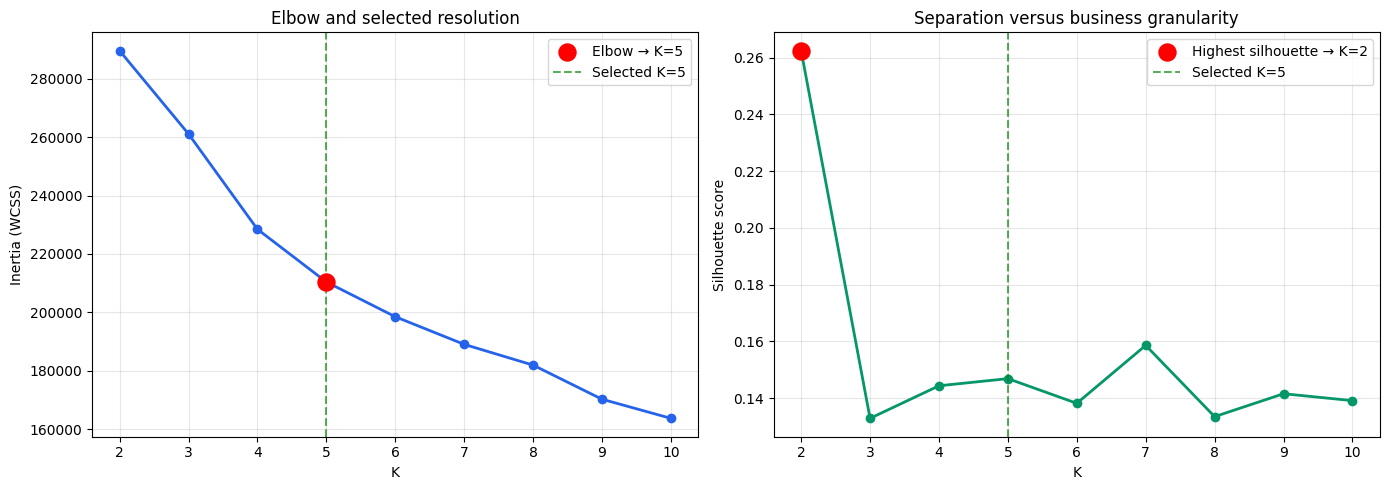

In [5]:
# Normalize both axes before measuring distance to the end-point chord;
# otherwise inertia units dominate K units.  The determinant below is the
# 2-D cross-product magnitude without NumPy's deprecated vector shortcut.
x_norm = (k_df['k'].to_numpy() - k_df['k'].min()) / (k_df['k'].max() - k_df['k'].min())
y_raw = k_df['inertia'].to_numpy()
y_norm = (y_raw - y_raw.min()) / (y_raw.max() - y_raw.min())
chord = np.array([x_norm[-1] - x_norm[0], y_norm[-1] - y_norm[0]])
points = np.column_stack([x_norm - x_norm[0], y_norm - y_norm[0]])
dists = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
elbow_k = int(k_df.iloc[int(np.argmax(dists))]['k'])
best_sil_k = int(k_df.loc[k_df['silhouette'].idxmax(), 'k'])
chosen = k_df.loc[k_df['k'].eq(K_OPTIMAL)].iloc[0]
stability_df = pd.read_csv(OUT_DIR / 'k_stability.csv')
stability_mean = stability_df.groupby('k')['adjusted_rand_index'].mean()
alternative = k_df.loc[k_df['k'].eq(6)].iloc[0]
alternative_7 = k_df.loc[k_df['k'].eq(7)].iloc[0]
print(f'Elbow reference          -> K = {elbow_k}')
print(f'Highest silhouette score -> K = {best_sil_k}')
print(f'\nK=5 evidence: silhouette={chosen.silhouette:.4f}, '
      f'Davies-Bouldin={chosen.davies_bouldin:.4f}, '
      f'minimum share={chosen.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[5]:.3f}.')
print(f'K=6 evidence: silhouette={alternative.silhouette:.4f}, '
      f'Davies-Bouldin={alternative.davies_bouldin:.4f}, '
      f'minimum share={alternative.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[6]:.3f}.')
print(f'K=7 evidence: silhouette={alternative_7.silhouette:.4f}, '
      f'Davies-Bouldin={alternative_7.davies_bouldin:.4f}, '
      f'minimum share={alternative_7.min_cluster_share:.2%}, '
      f'mean seed ARI={stability_mean.loc[7]:.3f}.')
print(f'\nSelected operating resolution: K = {K_OPTIMAL}')
unstable_alternatives = [k for k in [6, 7] if stability_mean.loc[k] < 0.90]
if unstable_alternatives:
    print('  More-granular alternatives are not retained because seed stability is below 0.90 for K='
          + ', '.join(map(str, unstable_alternatives)) + '.')
else:
    print('  K=6 and K=7 remain viable sensitivity cases; K=5 is retained for operational comparability.')
print('  Five profiles remain practical to compare and map to five distinct review questions.')
print('  These are portfolio segments for review planning, not applicant risk grades.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_df['k'], k_df['inertia'], 'o-', color='#2563EB', linewidth=2)
axes[0].scatter([elbow_k], [k_df.loc[k_df['k']==elbow_k, 'inertia'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Elbow → K={elbow_k}')
axes[0].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow and selected resolution'); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(k_df['k'], k_df['silhouette'], 'o-', color='#059669', linewidth=2)
axes[1].scatter([best_sil_k], [k_df.loc[k_df['k']==best_sil_k, 'silhouette'].iloc[0]],
                s=150, color='red', zorder=5, label=f'Highest silhouette → K={best_sil_k}')
axes[1].axvline(K_OPTIMAL, color='green', ls='--', alpha=.65, label=f'Selected K={K_OPTIMAL}')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Separation versus business granularity'); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); savefig_atomic(OUT_DIR / 'elbow_plot.png', dpi=160, bbox_inches='tight'); plt.show()


## 4. K-Means on all 356,255 combined applications

In [6]:
print('Running K-Means (K=5) on full data ...')
t0 = time.time()
kmeans = KMeans(n_clusters=K_OPTIMAL, n_init=10, max_iter=300, random_state=RANDOM_SEED)
kmeans_labels = kmeans.fit_predict(X_cluster)
print(f'  Done in {time.time()-t0:.1f}s | Inertia = {kmeans.inertia_:.1f}')

rng2 = np.random.default_rng(RANDOM_SEED)
sil_idx = rng2.choice(len(X_cluster), size=10000, replace=False)
sil_kmeans = silhouette_score(X_cluster[sil_idx], kmeans_labels[sil_idx])
print(f'  Silhouette Score (sample 10K): {sil_kmeans:.4f}')

unique, counts = np.unique(kmeans_labels, return_counts=True)
print(f'\nK-Means segment distribution:')
for cid, cnt in zip(unique, counts):
    pct = cnt/len(kmeans_labels)*100
    print(f'  Cluster {cid}: {cnt:>7,} applications ({pct:5.1f}%) {"█"*int(pct/2)}')

Running K-Means (K=5) on full data ...


  Done in 7.0s | Inertia = 4988829.0


  Silhouette Score (sample 10K): 0.1505

K-Means segment distribution:
  Cluster 0: 120,294 applications ( 33.8%) ████████████████
  Cluster 1:   7,622 applications (  2.1%) █
  Cluster 2:  51,426 applications ( 14.4%) ███████
  Cluster 3: 122,395 applications ( 34.4%) █████████████████
  Cluster 4:  54,518 applications ( 15.3%) ███████


## 5. Exploratory DBSCAN density view

DBSCAN asks a different question from K-Means: which sampled points lack
a sufficiently dense local neighbourhood? It runs on a reproducible
30,000-row UMAP projection and chooses `eps` from a normalized k-distance
knee. UMAP is useful for a readable local-neighbourhood map, but it can
distort global distance and density. The notebook checks the sample
against portfolio feature means, and DBSCAN noise is carried forward as
exploratory corroboration only. It is not a default label, a fraud label, or a full-portfolio
cluster label.


In [7]:
# DBSCAN is an exploratory density view on a reproducible random sample.
# UMAP makes the neighbourhood structure visible, but can distort global
# distance. A noise label can support a review, but it does not establish default or fraud.
DBSCAN_SAMPLE = 30000
MIN_SAMPLES = 15

rng3 = np.random.default_rng(RANDOM_SEED)
dbscan_idx = rng3.choice(len(X), size=DBSCAN_SAMPLE, replace=False)
X_db_raw = X[dbscan_idx]

representativeness = pd.DataFrame({
    'feature': feature_cols,
    'portfolio_mean': X.mean(axis=0),
    'sample_mean': X_db_raw.mean(axis=0),
})
representativeness['abs_mean_gap'] = (
    representativeness['sample_mean'] - representativeness['portfolio_mean']).abs()
representativeness.to_csv(OUT_DIR / 'dbscan_sample_validation.csv', index=False)

print(f'Step 1 - UMAP embedding {DBSCAN_SAMPLE:,} x {X_db_raw.shape[1]} features -> 2D ...')
t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.0,
                    metric='euclidean', random_state=RANDOM_SEED)
X_umap = reducer.fit_transform(X_db_raw)
print(f'  Done in {time.time()-t0:.1f}s')

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_umap)
kdist = np.sort(nn.kneighbors(X_umap)[0][:, -1])
xx = np.linspace(0, 1, len(kdist))
yy = (kdist - kdist.min()) / max(kdist.max() - kdist.min(), 1e-12)
chord = np.array([1.0, yy[-1] - yy[0]])
points = np.column_stack([xx, yy - yy[0]])
dline = np.abs(chord[0] * points[:, 1] - chord[1] * points[:, 0]) / np.linalg.norm(chord)
EPS = float(round(kdist[int(np.argmax(dline))], 3))
print(f'  eps (normalized k-distance knee, k={MIN_SAMPLES}) = {EPS}')

print(f'Step 2 - DBSCAN in UMAP space (eps={EPS}, min_samples={MIN_SAMPLES}) ...')
t0 = time.time()
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1)
dbscan_labels = dbscan.fit_predict(X_umap)
print(f'  Done in {time.time()-t0:.1f}s')
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int(np.sum(dbscan_labels == -1))
pct_noise = n_noise / len(dbscan_labels) * 100
print(f'  Density pockets found: {n_clusters_db}')
print(f'  Isolated sample points (label -1): {n_noise:,} ({pct_noise:.1f}%)')


Step 1 - UMAP embedding 30,000 x 42 features -> 2D ...


C:\Users\mario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 103.6s
  eps (normalized k-distance knee, k=15) = 0.104
Step 2 - DBSCAN in UMAP space (eps=0.104, min_samples=15) ...


  Done in 0.1s
  Density pockets found: 25
  Isolated sample points (label -1): 493 (1.6%)


## 6. Sampled Ward structural benchmark

Exact Ward clustering needs quadratic memory and is infeasible for
356,255 rows. The notebook fits Ward on a seeded 5,000-row sample, forms
sample-cluster centres, and assigns the full portfolio to the nearest
centre. This is an explicit approximation, not full-data hierarchical
clustering. Adjusted Rand index and normalized mutual information quantify
agreement with K-Means; a dendrogram remains a sample-level visual check.


In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import cdist

# Ward requires O(n^2) memory, so this is explicitly a sampled structural
# benchmark: fit Ward on 5K rows, form sample-cluster centres, and assign
# the full portfolio to the nearest centre. It is not exact full-data Ward.
HIER_SAMPLE = 5000
rng_h = np.random.default_rng(RANDOM_SEED)
hidx = rng_h.choice(len(X_cluster), size=HIER_SAMPLE, replace=False)
X_h = X_cluster[hidx]
print(f'Step 1 - Ward agglomerative benchmark on {HIER_SAMPLE:,} rows ...')
t0 = time.time()
agglo = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
sample_labels = agglo.fit_predict(X_h)
print(f'  Done in {time.time()-t0:.1f}s')
centroids = np.vstack([X_h[sample_labels == c].mean(axis=0) for c in range(K_OPTIMAL)])
print('Step 2 - Assign all rows to the nearest sampled-Ward centre ...')
hier_labels = cdist(X_cluster, centroids).argmin(axis=1).astype(np.int32)

method_agreement = pd.DataFrame([{
    'comparison': 'K-Means vs sampled Ward nearest-centre assignment',
    'adjusted_rand_index': adjusted_rand_score(kmeans_labels, hier_labels),
    'normalized_mutual_information': normalized_mutual_info_score(kmeans_labels, hier_labels),
}])
method_agreement.to_csv(OUT_DIR / 'method_agreement.csv', index=False)
print(method_agreement.to_string(index=False))

DENDRO_N = 1000
didx = rng_h.choice(len(X_h), size=min(DENDRO_N, len(X_h)), replace=False)
subcenters = X_h[didx]
linkage_methods = ['ward', 'complete', 'average']
linkage_results = {method: linkage(subcenters, method=method) for method in linkage_methods}

u_h, c_h = np.unique(hier_labels, return_counts=True)
print('\nSampled-Ward assignment distribution:')
for cid, cnt in zip(u_h, c_h):
    print(f'  Cluster {cid}: {cnt:>7,} applications ({cnt/len(hier_labels):5.1%})')


Step 1 - Ward agglomerative benchmark on 5,000 rows ...


  Done in 0.6s
Step 2 - Assign all rows to the nearest sampled-Ward centre ...
                                       comparison  adjusted_rand_index  normalized_mutual_information
K-Means vs sampled Ward nearest-centre assignment             0.584154                       0.592541

Sampled-Ward assignment distribution:
  Cluster 0: 134,316 applications (37.7%)
  Cluster 1: 145,131 applications (40.7%)
  Cluster 2:  12,452 applications ( 3.5%)
  Cluster 3:  57,822 applications (16.2%)
  Cluster 4:   6,534 applications ( 1.8%)


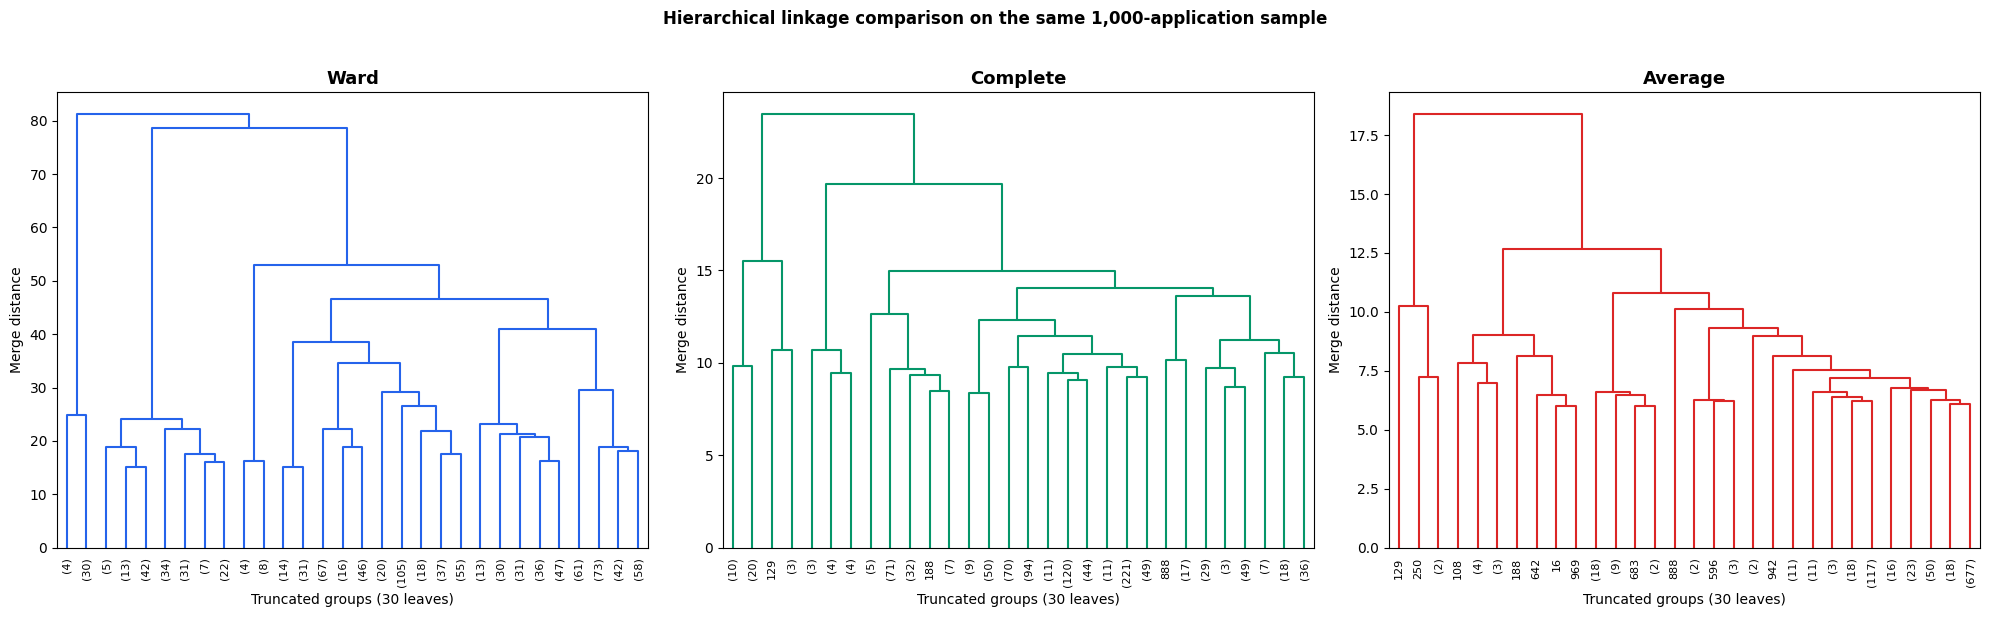

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['#2563EB', '#059669', '#DC2626']
for ax, method, color in zip(axes, linkage_methods, colors):
    dendrogram(linkage_results[method], ax=ax, truncate_mode='lastp', p=30,
               show_leaf_counts=True, leaf_rotation=90, leaf_font_size=8,
               color_threshold=0, above_threshold_color=color)
    ax.set_title(method.title(), fontsize=13, fontweight='bold')
    ax.set_xlabel('Truncated groups (30 leaves)'); ax.set_ylabel('Merge distance')
plt.suptitle(f'Hierarchical linkage comparison on the same {len(subcenters):,}-application sample',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Cluster maps in 2D

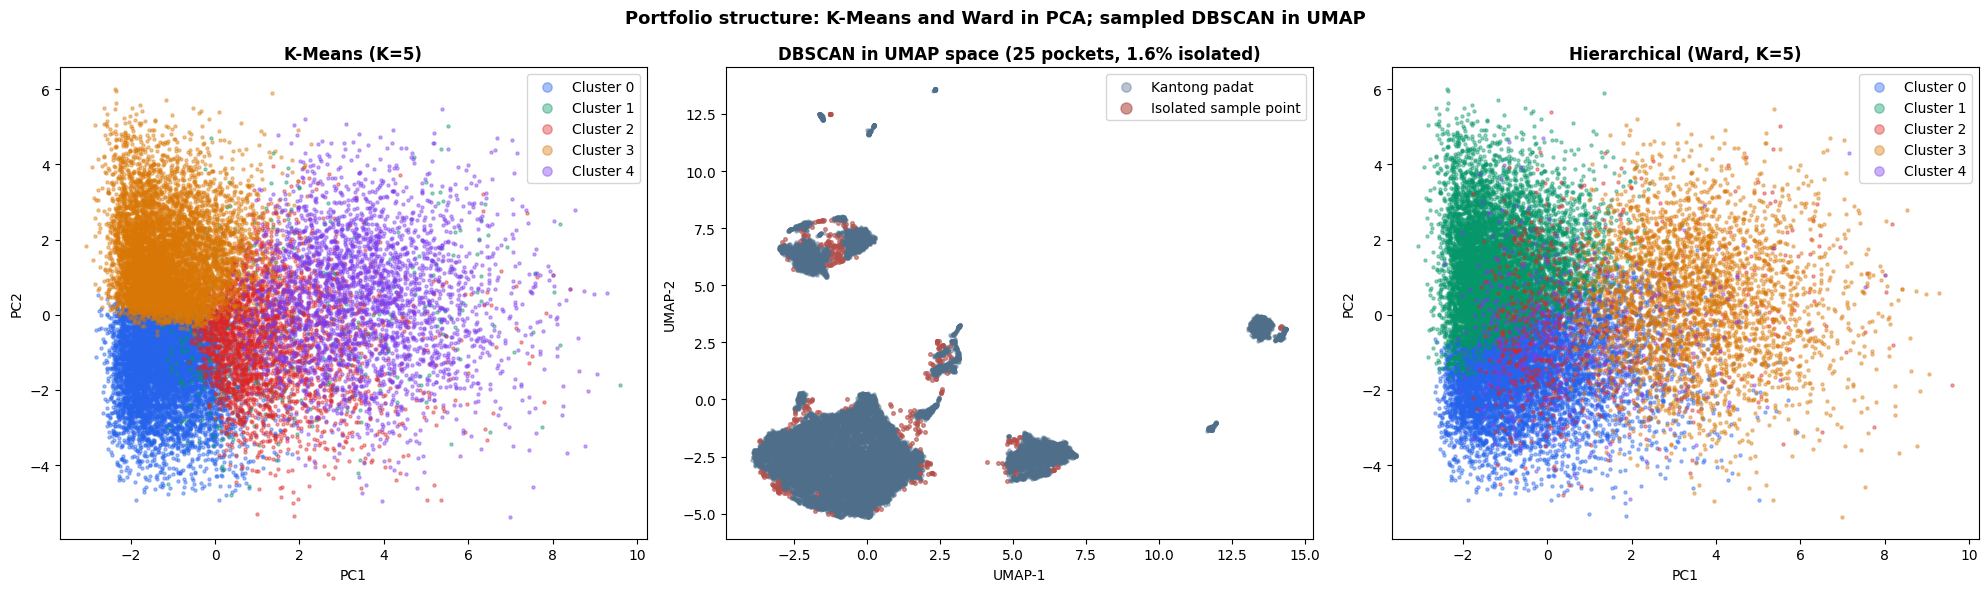

In [10]:
VIZ = 20000
rng4 = np.random.default_rng(RANDOM_SEED)
viz_idx = rng4.choice(len(X_2d), size=VIZ, replace=False)
COLORS = ['#2563EB', '#059669', '#DC2626', '#D97706', '#7C3AED']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for cid in range(K_OPTIMAL):
    mask = kmeans_labels[viz_idx] == cid
    axes[0].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[0].set_title(f'K-Means (K={K_OPTIMAL})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

viz_db_n = min(VIZ, len(dbscan_idx))
db_lbl = dbscan_labels[:viz_db_n]
noise_mask = db_lbl == -1
axes[1].scatter(X_umap[:viz_db_n][~noise_mask, 0], X_umap[:viz_db_n][~noise_mask, 1],
                c='#4E6E8A', label='Kantong padat', alpha=0.4, s=5)
axes[1].scatter(X_umap[:viz_db_n][noise_mask, 0], X_umap[:viz_db_n][noise_mask, 1],
                c='#B4504A', label='Isolated sample point', alpha=0.6, s=7)
axes[1].set_title(f'DBSCAN in UMAP space ({n_clusters_db} pockets, {pct_noise:.1f}% isolated)', fontweight='bold')
axes[1].set_xlabel('UMAP-1'); axes[1].set_ylabel('UMAP-2')
axes[1].legend(markerscale=3)

for cid in range(K_OPTIMAL):
    mask = hier_labels[viz_idx] == cid
    axes[2].scatter(X_2d[viz_idx][mask, 0], X_2d[viz_idx][mask, 1], c=COLORS[cid], label=f'Cluster {cid}', alpha=0.4, s=5)
axes[2].set_title(f'Hierarchical (Ward, K={K_OPTIMAL})', fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=3)

plt.suptitle('Portfolio structure: K-Means and Ward in PCA; sampled DBSCAN in UMAP', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'cluster_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save the cluster labels

In [11]:
labels_df = pd.DataFrame({
    'ROW_ID': np.arange(len(X_cluster)),
    'CLUSTER_KMEANS': kmeans_labels,
    'CLUSTER_HIER': hier_labels,
})
if 'SK_ID_CURR' in df.columns:
    labels_df.insert(1, 'SK_ID_CURR', df['SK_ID_CURR'].values)
labels_df['CLUSTER_DBSCAN'] = np.nan
labels_df.loc[dbscan_idx, 'CLUSTER_DBSCAN'] = dbscan_labels.astype(float)
labels_df['IS_OUTLIER'] = (labels_df['CLUSTER_DBSCAN'] == -1).astype('Int8')

def write_csv_atomic(frame, path):
    # Write beside the target, then atomically replace it. This avoids a
    # Windows failure seen when pandas truncates an existing dashboard
    # artefact while a filesystem indexer briefly holds a handle.
    path = Path(path)
    temp = path.with_name(f'.{path.stem}.tmp.csv')
    frame.to_csv(temp, index=False)
    for attempt in range(6):
        try:
            os.replace(temp, path)
            return
        except OSError:
            if attempt == 5:
                raise
            time.sleep(.5 * (attempt + 1))

write_csv_atomic(labels_df, OUT_DIR / 'cluster_labels.csv')
write_csv_atomic(labels_df, PROJECT_ROOT / 'datasets/final/cluster_labels.csv')
print('Saved cluster_labels.csv to:')
print(f'  {OUT_DIR / "cluster_labels.csv"}')
print(f'  {PROJECT_ROOT / "datasets/final/cluster_labels.csv"}  (for Phase 3 and 4)')

viz_export = pd.DataFrame({
    'PC1': X_2d[viz_idx, 0],
    'PC2': X_2d[viz_idx, 1],
    'CLUSTER_KMEANS': kmeans_labels[viz_idx],
})
write_csv_atomic(viz_export, OUT_DIR / 'cluster_viz_sample.csv')
print(f'Saved cluster_viz_sample.csv ({len(viz_export):,} rows for the dashboard)')
labels_df.head()


Saved cluster_labels.csv to:
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase2_clustering\cluster_labels.csv
  C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\datasets\final\cluster_labels.csv  (for Phase 3 and 4)
Saved cluster_viz_sample.csv (20,000 rows for the dashboard)


,ROW_ID,SK_ID_CURR,CLUSTER_KMEANS,CLUSTER_HIER,CLUSTER_DBSCAN,IS_OUTLIER
0,0,100002,0,4,3.0,0
1,1,100003,3,1,NaN,0
2,2,100004,0,0,NaN,0
3,3,100006,0,0,NaN,0
4,4,100007,3,0,0.0,0


## 9. Cluster profiling: what makes each segment different

For every feature we take its mean per cluster and compare it with the portfolio mean, measured in portfolio standard deviations. The features with the largest absolute standardized differences are the ones that set a cluster apart. This is a comparison unit, not a percentage change in the original feature.

In [12]:
TOP_N = 10
df_prof = pd.concat([df.reset_index(drop=True), labels_df[['CLUSTER_KMEANS']].reset_index(drop=True)], axis=1)
feat_cols = [c for c in df_prof.columns if c not in ['SK_ID_CURR', 'CLUSTER_KMEANS'] and pd.api.types.is_numeric_dtype(df_prof[c])]

profiles = df_prof.groupby('CLUSTER_KMEANS')[feat_cols].mean()
global_mean = df_prof[feat_cols].mean()
global_std = df_prof[feat_cols].std().replace(0, np.nan)
std_diff = profiles.sub(global_mean).div(global_std)

profiles.to_csv(OUT_DIR / 'cluster_profiles.csv')
print(f'Saved cluster_profiles.csv ({profiles.shape[0]} clusters x {profiles.shape[1]} features)')

summary_rows = []
top_features = {}
for cid in std_diff.index:
    row = std_diff.loc[cid].abs().sort_values(ascending=False)
    top_cols = row.head(TOP_N).index.tolist()
    top_df = pd.DataFrame({
        'fitur': top_cols,
        'std_diff': std_diff.loc[cid, top_cols].values,
        'arah': ['ABOVE' if v > 0 else 'BELOW' for v in std_diff.loc[cid, top_cols].values],
    }).sort_values('std_diff', key=abs, ascending=False)
    top_features[cid] = top_df
    for _, r in top_df.iterrows():
        summary_rows.append({'cluster_id': cid, 'fitur': r['fitur'], 'std_diff': round(r['std_diff'], 3), 'arah': r['arah']})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_DIR / 'cluster_summary.csv', index=False)
print(f'Saved cluster_summary.csv')

for cid in sorted(top_features.keys()):
    n = (labels_df['CLUSTER_KMEANS'] == cid).sum()
    pct = n / len(labels_df) * 100
    print(f'\n{"="*70}\nCLUSTER {cid} - {n:,} applications ({pct:.1f}%)\n{"-"*70}')
    for _, r in top_features[cid].iterrows():
        arrow = 'up' if r['arah'] == 'ABOVE' else 'down'
        print(f'  {r["fitur"]:42s} {r["std_diff"]:>+7.2f} SD  {arrow} {r["arah"]}')

Saved cluster_profiles.csv (5 clusters x 42 features)
Saved cluster_summary.csv

CLUSTER 0 - 120,294 applications (33.8%)
----------------------------------------------------------------------
  AMT_CREDIT                                   -0.87 SD  down BELOW
  AMT_ANNUITY                                  -0.75 SD  down BELOW
  CREDIT_TO_INCOME                             -0.63 SD  down BELOW
  CREDIT_TO_ANNUITY                            -0.55 SD  down BELOW
  ANNUITY_TO_INCOME                            -0.46 SD  down BELOW
  INST_COUNT                                   -0.45 SD  down BELOW
  CC_UTILIZATION_MAX                           -0.42 SD  down BELOW
  PREV_COUNT                                   -0.41 SD  down BELOW
  CC_UTILIZATION_MEAN                          -0.38 SD  down BELOW
  NAME_CONTRACT_TYPE                           -0.36 SD  down BELOW

CLUSTER 1 - 7,622 applications (2.1%)
----------------------------------------------------------------------
  INST_DPD_MEAN  

  PREV_COUNT                                   +1.46 SD  up ABOVE
  PREV_REFUSED_COUNT                           +1.25 SD  up ABOVE
  AMT_REQ_CREDIT_BUREAU_YEAR                   +1.06 SD  up ABOVE
  POS_MONTHS_COUNT                             +1.02 SD  up ABOVE
  PREV_APPROVAL_RATE                           -0.65 SD  down BELOW
  BUREAU_COUNT                                 +0.47 SD  up ABOVE
  INST_COUNT                                   +0.43 SD  up ABOVE
  CC_UTILIZATION_MEAN                          -0.33 SD  down BELOW
  CREDIT_TO_INCOME                             -0.32 SD  down BELOW
  CC_UTILIZATION_MAX                           -0.31 SD  down BELOW

CLUSTER 3 - 122,395 applications (34.4%)
----------------------------------------------------------------------
  AMT_CREDIT                                   +0.83 SD  up ABOVE
  CREDIT_TO_INCOME                             +0.76 SD  up ABOVE
  AMT_ANNUITY                                  +0.70 SD  up ABOVE
  ANNUITY_TO_INCOME  

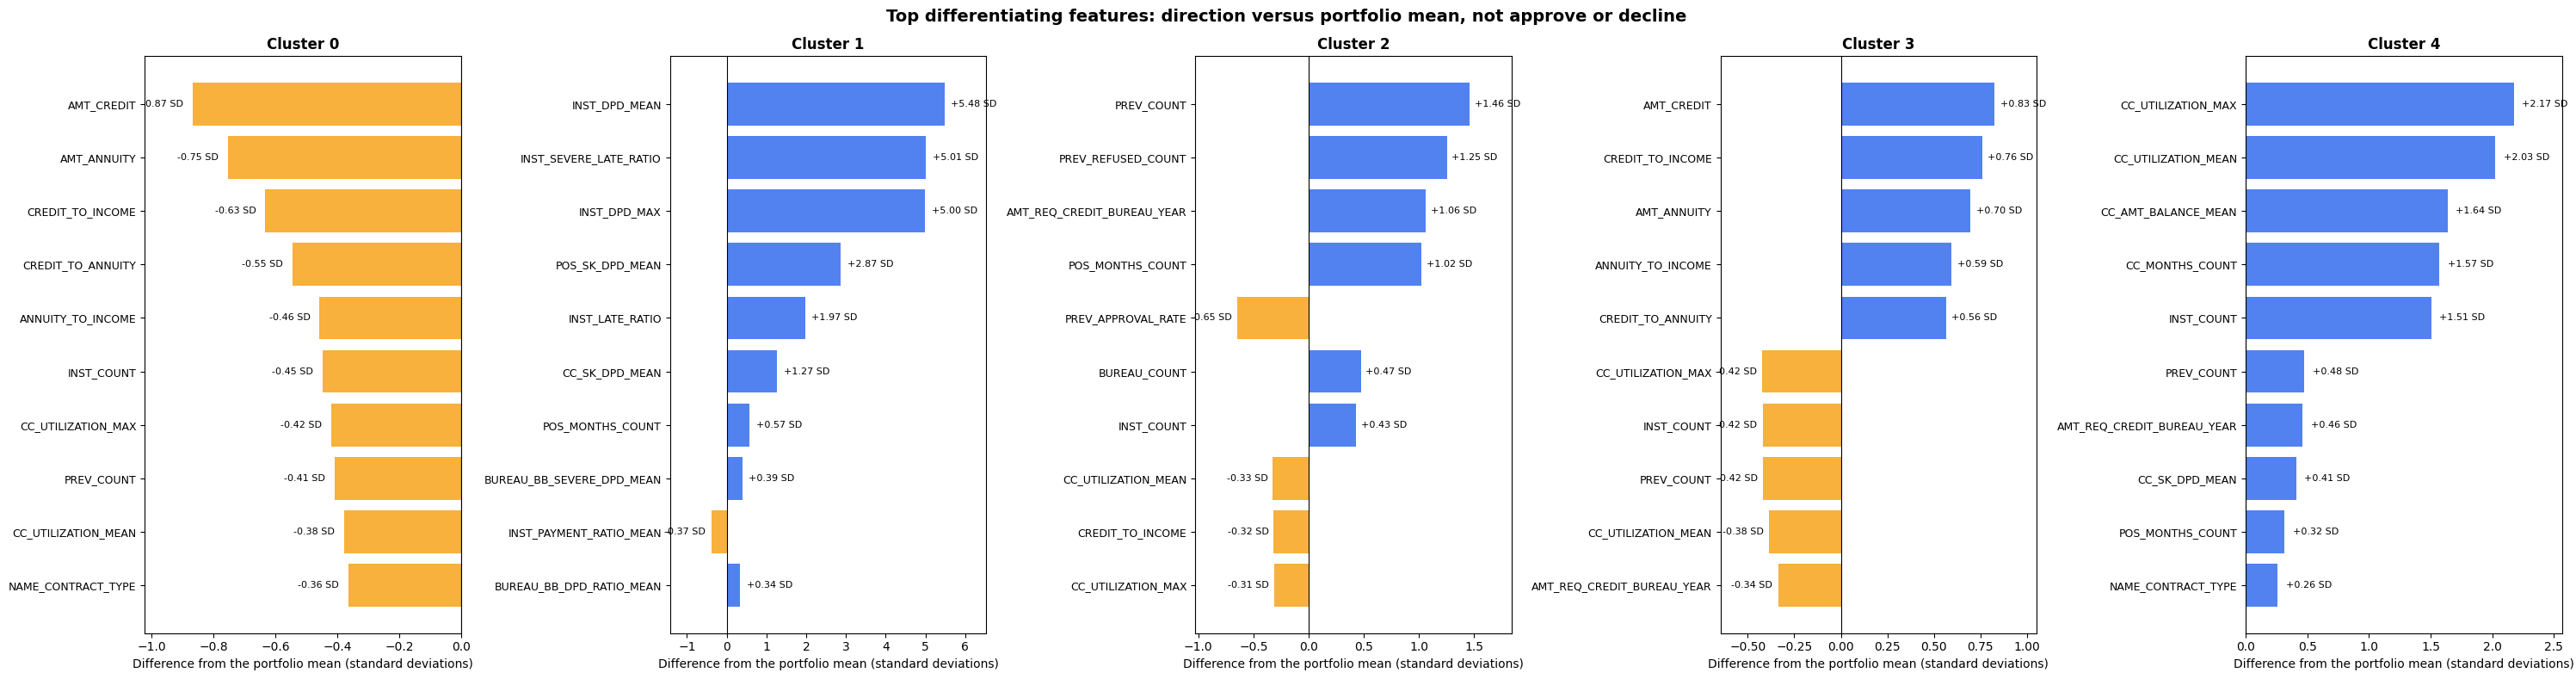

In [13]:
n_clusters = len(top_features)
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 8))
if n_clusters == 1:
    axes = [axes]
for ax, cid in zip(axes, sorted(top_features.keys())):
    tdf = top_features[cid].head(TOP_N)
    values = tdf['std_diff'].values
    labels = tdf['fitur'].values
    colors_bar = ['#2563EB' if v > 0 else '#F59E0B' for v in values]
    bars = ax.barh(range(len(values)), values, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(labels, fontsize=9)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Difference from the portfolio mean (standard deviations)')
    ax.set_title(f'Cluster {cid}', fontweight='bold')
    ax.invert_yaxis()
    label_pad = max(np.max(np.abs(values)) * 0.03, 0.03)
    for bar, val in zip(bars, values):
        x = val + (label_pad if val >= 0 else -label_pad)
        ax.text(x, bar.get_y() + bar.get_height()/2, f'{val:+.2f} SD', va='center', fontsize=8, ha='left' if val >= 0 else 'right')
    ax.margins(x=0.18)
plt.suptitle('Top differentiating features: direction versus portfolio mean, not approve or decline', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'cluster_profile_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Business interpretation and segment naming

The most distinctive features are translated into plain segment names and review questions. These names describe patterns across the 356,255 combined applications; they are not applicant risk grades. `Lower-Intensity Credit Footprint` means lower product activity relative to the other segments, not an absence of usable history. Card utilisation, balances, arrears, and repayment measures come from previous Home Credit accounts and payment records. They describe recorded history, not a verified current balance or current payment problem. The external scores are opaque supporting indicators, so they are used only to prompt corroboration with direct bureau, income, and repayment evidence. A reviewer still needs to verify source coverage, recency, current obligations, and affordability before acting. Names and sizes are saved to `cluster_names.csv` so later phases use full business names instead of cluster numbers that can change between runs.

In [14]:
# Assign one unique, descriptive name to each cluster from its dominant
# business pattern. Names describe portfolio geometry; they are not credit
# decisions and must never replace applicant-level repayment assessment.
def mean_available(frame, columns):
    cols = [c for c in columns if c in frame.columns]
    return frame[cols].mean(axis=1) if cols else pd.Series(0.0, index=frame.index)

score_table = pd.DataFrame(index=profiles.index)
score_table['repayment_stress'] = mean_available(profiles, [
    'INST_DPD_MEAN', 'INST_DPD_MAX', 'INST_LATE_RATIO',
    'INST_SEVERE_LATE_RATIO', 'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'])
score_table['card_intensity'] = mean_available(profiles, [
    'CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN', 'CC_MONTHS_COUNT'])
score_table['relationship_depth'] = mean_available(profiles, [
    'PREV_COUNT', 'BUREAU_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'])
score_table['borrowing_scale'] = mean_available(profiles, [
    'AMT_CREDIT', 'AMT_ANNUITY', 'CREDIT_TO_INCOME'])

remaining = set(int(c) for c in profiles.index)
assignments = {}
def take_highest(score, name):
    cid = int(score.loc[list(remaining)].idxmax())
    assignments[cid] = name
    remaining.remove(cid)

take_highest(score_table['repayment_stress'], 'Repayment-Stress History')
take_highest(score_table['card_intensity'], 'Historical Card-Use Intensity')
take_highest(score_table['relationship_depth'], 'History-Rich Credit User')
take_highest(score_table['borrowing_scale'], 'Larger-Loan Affordability')
assignments[remaining.pop()] = 'Lower-Intensity Credit Footprint'

META = {
    'Repayment-Stress History': {
        'risk': 'Repayment review',
        'profile': 'Late payments in recorded instalment history are the strongest differentiating pattern.',
        'watch': 'When the delays happened, how severe they were, whether they were cured, and current affordability.',
        'action': 'Review the repayment timeline and current affordability. For existing hardship, follow the customer-contact or restructuring policy.'},
    'Historical Card-Use Intensity': {
        'risk': 'Historical revolving-credit review',
        'profile': 'Recorded use of previous Home Credit card accounts dominates this profile.',
        'watch': 'Whether a revolving facility is still open, plus its verified current balance, utilisation, arrears, and affordability.',
        'action': 'Use the history to focus the review. Assess limit suitability only after confirming that a current revolving facility exists and verifying its present balance and payment status.'},
    'History-Rich Credit User': {
        'risk': 'Credit-history review',
        'profile': 'This profile has longer internal and external credit history than the other groups.',
        'watch': 'Whether earlier refusals or arrears remain relevant now.',
        'action': 'Compare earlier decisions with current obligations. Use the extra history to verify the present position, not to assume it.'},
    'Larger-Loan Affordability': {
        'risk': 'Affordability review',
        'profile': 'Larger current-loan amounts and scheduled payments distinguish this profile.',
        'watch': 'Verified income, total obligations, and whether the scheduled payment remains affordable if income falls.',
        'action': 'Confirm sustainable income and test the proposed payment under a lower-income scenario before any credit action.'},
    'Lower-Intensity Credit Footprint': {
        'risk': 'Standard evidence review',
        'profile': 'Lower product activity and smaller loan amounts than the other portfolio segments.',
        'watch': 'Which sources are actually missing; lower activity does not mean that useful history is absent or that payment risk is lower.',
        'action': 'Use standard underwriting. Ask for permitted supporting evidence only when a relevant source is genuinely unavailable.'},
}

SLUG_BY_NAME = {
    'History-Rich Credit User': 'history_rich',
    'Lower-Intensity Credit Footprint': 'lower_intensity',
    'Historical Card-Use Intensity': 'card_intensive',
    'Larger-Loan Affordability': 'larger_loan',
    'Repayment-Stress History': 'repayment_stress',
}
names_rows = []
for cid in sorted(assignments):
    name = assignments[cid]
    meta = META[name]
    names_rows.append({
        'cluster_id': cid,
        'nama': name,
        'slug': SLUG_BY_NAME[name],
        'profil_risiko': meta['risk'],
        'profile_summary': meta['profile'],
        'watch_items': meta['watch'],
        'recommended_action': meta['action'],
        'n_applicants': int((labels_df['CLUSTER_KMEANS'] == cid).sum()),
    })
    print(f'Cluster {cid}: {name}; review focus: {meta["risk"]}')

names_df = pd.DataFrame(names_rows)
write_csv_atomic(names_df, OUT_DIR / 'cluster_names.csv')
write_csv_atomic(names_df, PROJECT_ROOT / 'datasets/final/cluster_names.csv')
print('\nSaved cluster_names.csv (results + datasets/final):')
print(names_df.to_string(index=False))


Cluster 0: Lower-Intensity Credit Footprint; review focus: Standard evidence review
Cluster 1: Repayment-Stress History; review focus: Repayment review
Cluster 2: History-Rich Credit User; review focus: Credit-history review
Cluster 3: Larger-Loan Affordability; review focus: Affordability review
Cluster 4: Historical Card-Use Intensity; review focus: Historical revolving-credit review

Saved cluster_names.csv (results + datasets/final):
 cluster_id                             nama             slug                      profil_risiko                                                                         profile_summary                                                                                                                   watch_items                                                                                                                                                                 recommended_action  n_applicants
          0 Lower-Intensity Credit Footprint  lower_in

---
Phase 2 done. The artefacts are in `results/phase2_clustering/`, and `datasets/final/cluster_labels.csv` carries the segment assignments forward to Phase 3 and Phase 4.

---
## 11. Comparable business view and DBSCAN map

The earlier small multiples show the strongest features separately for each
cluster, but separate axes make comparison unnecessarily hard. The heatmap
below puts all five segments on one scale using six domain dimensions. Blue
means "more of the named dimension" and orange means "less"; the colours do
not mean approve or decline. A second view shows the DBSCAN UMAP
map so readers can inspect the isolated points instead of seeing only a count.


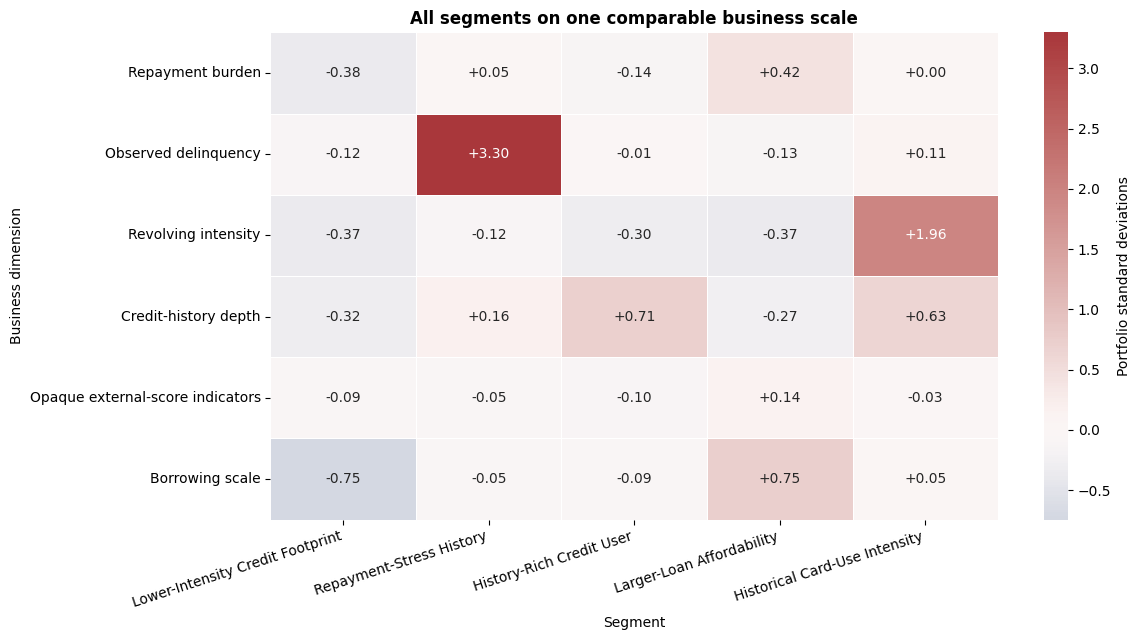

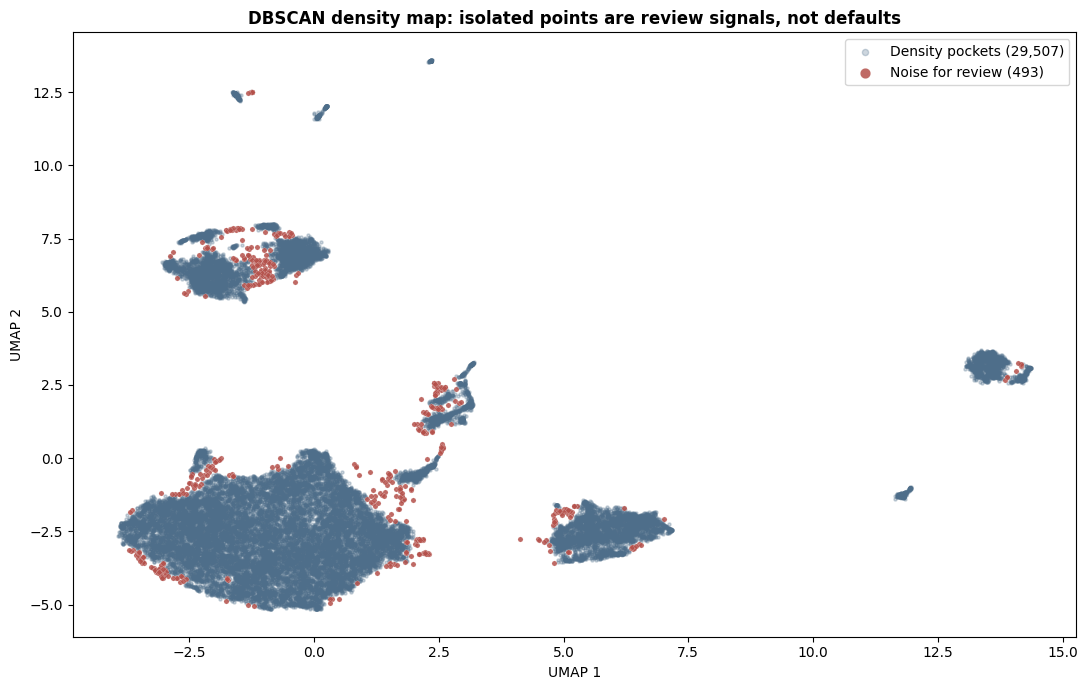

Saved comparable cluster view, business medians, action matrix, and 30,000-row DBSCAN map.


In [15]:
import seaborn as sns

business = pd.read_csv(PROJECT_ROOT / 'datasets/final/features_business.csv')
business_labeled = business.merge(
    labels_df[['ROW_ID', 'CLUSTER_KMEANS']], on='ROW_ID', how='inner', validate='one_to_one')
NAME_BY_CID = dict(zip(names_df['cluster_id'], names_df['nama']))
business_labeled['Segment'] = business_labeled['CLUSTER_KMEANS'].map(NAME_BY_CID)

dimension_features = {
    'Repayment burden': ['ANNUITY_TO_INCOME', 'CREDIT_TO_INCOME', 'BUREAU_DEBT_TO_CREDIT_RATIO'],
    'Observed delinquency': ['INST_DPD_MAX', 'INST_LATE_RATIO', 'INST_SEVERE_LATE_RATIO',
                             'POS_SK_DPD_MEAN', 'CC_SK_DPD_MEAN'],
    'Revolving intensity': ['CC_UTILIZATION_MEAN', 'CC_UTILIZATION_MAX', 'CC_AMT_BALANCE_MEAN'],
    'Credit-history depth': ['BUREAU_COUNT', 'PREV_COUNT', 'POS_MONTHS_COUNT', 'CC_MONTHS_COUNT'],
    'Opaque external-score indicators': ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'Borrowing scale': ['AMT_CREDIT', 'AMT_ANNUITY'],
}

numeric = business_labeled.select_dtypes(include=np.number).copy()
standardized = pd.DataFrame(index=numeric.index)
for col in sorted({c for cols in dimension_features.values() for c in cols if c in numeric.columns}):
    values = numeric[col].replace([np.inf, -np.inf], np.nan)
    lo, hi = values.quantile([.01, .99])
    clipped = values.clip(lo, hi)
    std = clipped.std()
    standardized[col] = (clipped - clipped.mean()) / std if std and np.isfinite(std) else 0.0

dimensions = pd.DataFrame(index=business_labeled.index)
for dimension, columns in dimension_features.items():
    use = [c for c in columns if c in standardized.columns]
    dimensions[dimension] = standardized[use].mean(axis=1)
dimensions['CLUSTER_KMEANS'] = business_labeled['CLUSTER_KMEANS'].values
comparison = dimensions.groupby('CLUSTER_KMEANS').mean().T
comparison.columns = [NAME_BY_CID[int(c)] for c in comparison.columns]
comparison = comparison[names_df.sort_values('cluster_id')['nama'].tolist()]

comparison_long = comparison.rename_axis('business_dimension').reset_index().melt(
    id_vars='business_dimension', var_name='Segment', value_name='portfolio_sd')
comparison_long.to_csv(OUT_DIR / 'cluster_comparison_long.csv', index=False)

business_summary = business_labeled.groupby(['CLUSTER_KMEANS', 'Segment']).agg(
    applicants=('SK_ID_CURR', 'size'),
    median_income=('AMT_INCOME_TOTAL', 'median'),
    median_credit=('AMT_CREDIT', 'median'),
    median_credit_to_income=('CREDIT_TO_INCOME', 'median'),
    median_annuity_to_income=('ANNUITY_TO_INCOME', 'median'),
    median_installment_late_share=('INST_LATE_RATIO', 'median'),
    median_external_score_2=('EXT_SOURCE_2', 'median'),
    median_card_utilisation=('CC_UTILIZATION_MEAN', 'median'),
).reset_index()
business_summary.to_csv(OUT_DIR / 'cluster_business_summary.csv', index=False)
names_df[['cluster_id', 'nama', 'profile_summary', 'watch_items', 'recommended_action']].to_csv(
    OUT_DIR / 'cluster_action_matrix.csv', index=False)

fig, ax = plt.subplots(figsize=(12, 6.5))
sns.heatmap(comparison, cmap='vlag', center=0, annot=True, fmt='+.2f',
            linewidths=.6, cbar_kws={'label': 'Portfolio standard deviations'}, ax=ax)
ax.set_xlabel('Segment'); ax.set_ylabel('Business dimension')
ax.set_title('All segments on one comparable business scale', fontweight='bold')
plt.xticks(rotation=18, ha='right')
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_cluster_comparison.png', dpi=170, bbox_inches='tight')
plt.show()

dbscan_export = pd.DataFrame({
    'ROW_ID': dbscan_idx,
    'SK_ID_CURR': df.iloc[dbscan_idx]['SK_ID_CURR'].to_numpy(),
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'DBSCAN_LABEL': dbscan_labels,
    'IS_NOISE': (dbscan_labels == -1).astype(int),
    'CLUSTER_KMEANS': kmeans_labels[dbscan_idx],
})
dbscan_export['Segment'] = dbscan_export['CLUSTER_KMEANS'].map(NAME_BY_CID)
dbscan_export.to_csv(OUT_DIR / 'dbscan_umap_sample.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 7))
dense = dbscan_export[dbscan_export['IS_NOISE'] == 0]
noise = dbscan_export[dbscan_export['IS_NOISE'] == 1]
ax.scatter(dense['UMAP1'], dense['UMAP2'], s=5, alpha=.28, c='#4E6E8A',
           label=f'Density pockets ({len(dense):,})')
ax.scatter(noise['UMAP1'], noise['UMAP2'], s=14, alpha=.85, c='#B4504A',
           edgecolors='white', linewidths=.15, label=f'Noise for review ({len(noise):,})')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title('DBSCAN density map: isolated points are review signals, not defaults', fontweight='bold')
ax.legend(markerscale=2)
plt.tight_layout()
savefig_atomic(OUT_DIR / 'plot_dbscan_umap.png', dpi=170, bbox_inches='tight')
plt.show()

print(f'Saved comparable cluster view, business medians, action matrix, and {len(dbscan_export):,}-row DBSCAN map.')
